In [ ]:
!pip install timm albumentations

In [ ]:
from pathlib import Path

BASE = Path("/kaggle/input")

for p in BASE.iterdir():
    print(p)

In [ ]:
LABEL_MAP = {

    # paper family
    "paper": "Paper",
    "cardboard": "Cardboard",

    # plastic
    "plastic": "Plastic",

    # metal
    "metal": "Metal",

    "Biological":"Biological",

    # glass types merged
    "glass": "Glass",
    "green-glass": "Glass",
    "brown-glass": "Glass",
    "white-glass": "Glass",

    # textile
    "clothes": "Textile",
    "shoes": "Textile",

    # hazardous
    "batteries": "E-Waste",
    "battery":"E-Waste",
    # trash
    "trash": "General_Waste"
}

print("Label map loaded ✅")

Label map loaded ✅


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -q /content/drive/MyDrive/data.zip -d /content/raw_data

In [ ]:
from pathlib import Path

# In Colab, '/content' is the default root directory
OUT_DIR = Path("/content/unified_dataset")
OUT_DIR.mkdir(exist_ok=True)

print(f"Folder created at: {OUT_DIR}")

Folder created at: /content/unified_dataset


In [ ]:
import shutil
from tqdm import tqdm
from pathlib import Path

# 1. Update these paths to match your unzipped folders in Colab
DATASETS = [
    Path("/content/raw_data/dataset-resized"),
    Path("/content/raw_data/trashbox_limited"),
    Path("/content/raw_data/garbage_classification")
]

# Ensure your Output Directory exists
OUT_DIR = Path("/content/unified_dataset")
OUT_DIR.mkdir(exist_ok=True)

img_id = 0

for dataset in DATASETS:
    # Check if the path actually exists to avoid errors
    if not dataset.exists():
        print(f"⚠️ Warning: {dataset} not found. Skipping...")
        continue

    print(f"\nProcessing: {dataset.name}")

    for class_folder in dataset.rglob("*"):
        if not class_folder.is_dir():
            continue

        class_name = class_folder.name.lower()

        # This checks if the folder name (e.g., 'glass') is in your LABEL_MAP
        if class_name not in LABEL_MAP:
            continue

        new_label = LABEL_MAP[class_name]
        dest_folder = OUT_DIR / new_label
        dest_folder.mkdir(exist_ok=True)

        # Support common image formats
        images = []
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            images.extend(list(class_folder.glob(ext)))

        for img in tqdm(images, desc=f"Merging {class_name}", leave=False):
            new_name = f"{new_label}_{img_id}.jpg"
            shutil.copy(img, dest_folder / new_name)
            img_id += 1

print("\n✅ DATA MERGED SUCCESSFULLY")
print(f"Total images processed: {img_id}")


Processing: dataset-resized



Processing: trashbox_limited



Processing: garbage_classification



✅ DATA MERGED SUCCESSFULLY
Total images processed: 27388


In [ ]:
for cls in OUT_DIR.iterdir():
    print(cls.name, ":", len(list(cls.glob("*"))))

Plastic : 3196
Paper : 3788
Cardboard : 3391
General_Waste : 834
E-Waste : 945
Glass : 4647
Textile : 7302
Metal : 3285


In [ ]:
import random
import shutil
from pathlib import Path

# 1. Update paths for Colab
TRAIN_DIR = Path("/content/data/train")
VAL_DIR = Path("/content/data/val")

# Ensure OUT_DIR is what we defined earlier
OUT_DIR = Path("/content/unified_dataset")

# 2. Clear existing split folders if you are re-running this
if TRAIN_DIR.exists():
    shutil.rmtree(TRAIN_DIR.parent)

for cls in OUT_DIR.iterdir():
    if not cls.is_dir():
        continue

    # Get all images in this unified class folder
    images = list(cls.glob("*"))
    random.shuffle(images)

    # 80/20 Split
    split = int(0.8 * len(images))
    train_imgs = images[:split]
    val_imgs = images[split:]

    # Create directories
    (TRAIN_DIR/cls.name).mkdir(parents=True, exist_ok=True)
    (VAL_DIR/cls.name).mkdir(parents=True, exist_ok=True)

    # Use 'move' instead of 'copy' to save space in Colab's temporary storage
    for img in train_imgs:
        shutil.copy(img, TRAIN_DIR/cls.name/img.name)

    for img in val_imgs:
        shutil.copy(img, VAL_DIR/cls.name/img.name)

print(f"✅ Train/Val split ready!")
print(f"Training images: {len(list(TRAIN_DIR.glob('*/*')))}")
print(f"Validation images: {len(list(VAL_DIR.glob('*/*')))}")

✅ Train/Val split ready!
Training images: 21907
Validation images: 5481


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print(train_dataset.classes)

['Cardboard', 'E-Waste', 'General_Waste', 'Glass', 'Metal', 'Paper', 'Plastic', 'Textile']


In [ ]:
from collections import Counter

labels = [label for _, label in train_dataset.samples]
count = Counter(labels)

for cls, idx in train_dataset.class_to_idx.items():
    print(cls, count[idx])

Cardboard 2712
E-Waste 756
General_Waste 667
Glass 3717
Metal 2628
Paper 3030
Plastic 2556
Textile 5841


In [ ]:
import torch
import numpy as np

class_counts = np.array([count[i] for i in range(len(count))])

weights = 1. / class_counts
weights = weights / weights.sum()

class_weights = torch.tensor(weights, dtype=torch.float32).cuda()

class_weights

tensor([0.0779, 0.2795, 0.3168, 0.0568, 0.0804, 0.0697, 0.0827, 0.0362],
       device='cuda:0')

In [ ]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
from torch.utils.data import WeightedRandomSampler

sample_weights = [weights[label] for _, label in train_dataset.samples]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler
)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from tqdm import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(weights="IMAGENET1K_V1")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]


In [ ]:
num_classes = 8

model.classifier[1] = nn.Linear(
    model.last_channel,
    num_classes
)

model = model.to(device)

In [ ]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

In [ ]:
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

In [ ]:
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [ ]:
val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [ ]:
epochs = 10
best_acc = 0

for epoch in range(epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    # ---------- VALIDATION ----------
    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    scheduler.step()

    print(f"\nEpoch {epoch+1}")
    print(f"Train Acc: {train_acc:.4f}")
    print(f"Val Acc:   {val_acc:.4f}")

    # save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Model Saved")

100%|██████████| 685/685 [02:21<00:00,  4.85it/s]



Epoch 1
Train Acc: 0.8261
Val Acc:   0.8816
✅ Model Saved


100%|██████████| 685/685 [02:21<00:00,  4.84it/s]



Epoch 2
Train Acc: 0.9210
Val Acc:   0.9029
✅ Model Saved


100%|██████████| 685/685 [02:22<00:00,  4.81it/s]


...


Epoch 8
Train Acc: 0.9956
Val Acc:   0.9520
✅ Model Saved


100%|██████████| 685/685 [02:25<00:00,  4.70it/s]



Epoch 9
Train Acc: 0.9976
Val Acc:   0.9544
✅ Model Saved


100%|██████████| 685/685 [02:22<00:00,  4.80it/s]



Epoch 10
Train Acc: 0.9981
Val Acc:   0.9526


In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [ ]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        preds = torch.argmax(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# 1. Print the evaluation metrics you imported
print("\n--- Classification Report ---")
print(classification_report(all_labels, all_preds))

print("\n--- Confusion Matrix ---")
print(confusion_matrix(all_labels, all_preds))

# 2. Save the model's state dictionary (Recommended PyTorch Method)
save_path = "waste_model_weights.pth"
torch.save(model.state_dict(), save_path)
print(f"\nModel weights saved successfully to {save_path}")


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       679
           1       0.94      0.98      0.96       189
           2       0.94      0.95      0.94       167
           3       0.95      0.94      0.94       930
           4       0.91      0.93      0.92       657
           5       0.94      0.96      0.95       758
           6       0.93      0.90      0.92       640
           7       1.00      0.98      0.99      1461

    accuracy                           0.95      5481
   macro avg       0.94      0.95      0.95      5481
weighted avg       0.95      0.95      0.95      5481


--- Confusion Matrix ---
[[ 647    1    3    4   10   14    0    0]
 [   0  186    0    0    2    1    0    0]
 [   3    0  159    0    3    2    0    0]
 [  12    1    1  870   22    3   20    1]
 [   7    8    0    7  614    8   10    3]
 [   7    1    3    1    4  731   11    0]
 [   2    1    2   27   14   16  5

In [ ]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))

               precision    recall  f1-score   support

    Cardboard       0.95      0.95      0.95       679
      E-Waste       0.94      0.98      0.96       189
General_Waste       0.94      0.95      0.94       167
        Glass       0.95      0.94      0.94       930
        Metal       0.91      0.93      0.92       657
        Paper       0.94      0.96      0.95       758
      Plastic       0.93      0.90      0.92       640
      Textile       1.00      0.98      0.99      1461

     accuracy                           0.95      5481
    macro avg       0.94      0.95      0.95      5481
 weighted avg       0.95      0.95      0.95      5481



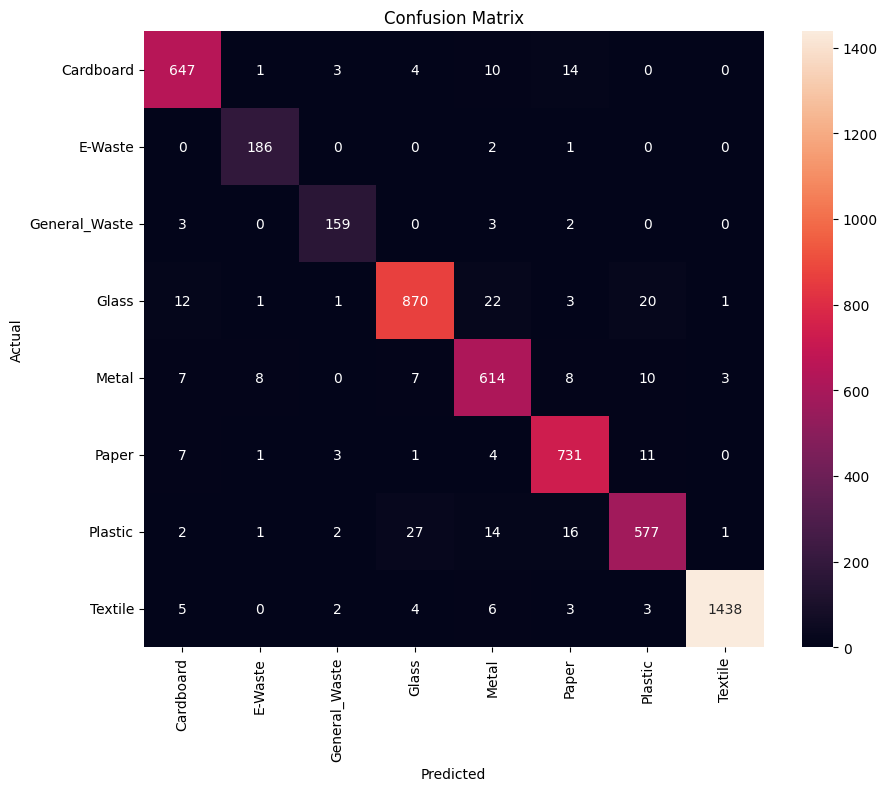

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

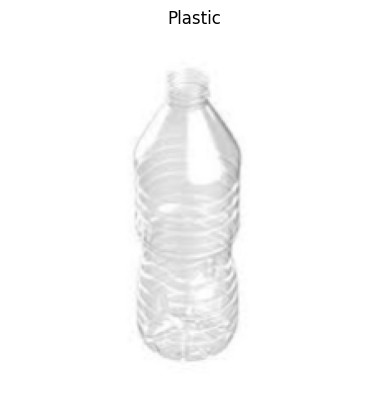

In [ ]:
import random
from PIL import Image
import matplotlib.pyplot as plt

idx = random.randint(0, len(val_dataset)-1)
img, label = val_dataset[idx]

plt.imshow(img.permute(1,2,0))
plt.title(train_dataset.classes[label])
plt.axis("off")

In [ ]:
!pip install gradio

In [ ]:
import torch
from torchvision import models, transforms
from PIL import Image
import torch.nn.functional as F

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.mobilenet_v2(weights=None)

model.classifier[1] = torch.nn.Linear(
    model.last_channel,
    8   # number of classes
)

model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.to(device)
model.eval()

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [ ]:
CLASSES = [
    "Cardboard",
    "E-Waste",
    "General_Waste",
    "Glass",
    "Metal",
    "Paper",
    "Plastic",
    "Textile"
]

In [ ]:
WASTE_INFO = {
    "Plastic": ("Recyclable ♻️", "Send to plastic recycling", 1.8),
    "Metal": ("Recyclable ♻️", "Scrap metal recovery", 4.5),
    "Glass": ("Recyclable ♻️", "Glass recycling facility", 1.2),
    "Paper": ("Recyclable ♻️", "Paper recycling", 1.3),
    "Cardboard": ("Recyclable ♻️", "Cardboard recycling", 1.1),
    "Textile": ("Non-Recyclable", "Textile recovery/bin", 0.3),
    "General_Waste": ("Landfill", "General disposal", 0.0),
    "E-Waste": ("Hazardous ⚠️", "Authorized e-waste recycler", 8.0)
}

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [ ]:
def predict_waste(image):
    image = Image.fromarray(image).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(tensor)
        probs = F.softmax(outputs, dim=1)

    confidence, pred = torch.max(probs, 1)

    label = CLASSES[pred.item()]
    conf = confidence.item()

    category, action, carbon = WASTE_INFO[label]

    # uncertainty awareness (judge favorite)
    if conf < 0.6:
        # Return as a dict so gr.Label doesn't crash
        return {"⚠️ Uncertain prediction — needs manual verification.": float(conf)}

    # Return a flat dictionary of class names to probabilities
    return {CLASSES[i]: float(probs[0][i]) for i in range(len(CLASSES))}

In [ ]:
import gradio as gr

demo = gr.Interface(
    fn=predict_waste,
    inputs=gr.Image(type="numpy"),
    outputs=gr.Label(num_top_classes=3),
    title="🌱 AI Waste Intelligence System",
    description="Upload an image or use webcam to classify waste and estimate sustainability impact."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://747de2c7c01a9aad10.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
